In [1]:
file_path = "data_scaling_skewed_data.csv"

In [2]:
import pandas as pd
df = pd.read_csv(file_path)

In [3]:
df.head()

,Student_ID,Study_Hours,Age,Attendance,Family_Income,Internet_Usage_Hours,Exam_Score
0,1,4.79,25,68.22,26401.83,5.13,68.46
1,2,2.99,25,72.62,29899.43,10.14,58.53
2,3,2.76,24,87.15,84956.82,6.63,50.72
3,4,2.76,20,87.14,15797.16,0.99,72.44
4,5,9.30,18,87.15,44019.48,2.10,60.92


In [4]:
df.shape

(100, 7)

In [5]:
df.isna().sum()

Student_ID              0
Study_Hours             0
Age                     0
Attendance              3
Family_Income           0
Internet_Usage_Hours    2
Exam_Score              0
dtype: int64

In [6]:
df.info

<bound method DataFrame.info of     Student_ID  Study_Hours  Age  Attendance  Family_Income  \
0            1         4.79   25       68.22       26401.83   
1            2         2.99   25       72.62       29899.43   
2            3         2.76   24       87.15       84956.82   
3            4         2.76   20       87.14       15797.16   
4            5         9.30   18       87.15       44019.48   
..         ...          ...  ...         ...            ...   
95          96         1.81   25       88.30       81963.94   
96          97        10.84   18       73.71        6406.16   
97          98         4.71   18       76.40       15686.61   
98          99         1.40   20       89.47       27030.45   
99         100         5.81   23       88.10       28065.11   

    Internet_Usage_Hours  Exam_Score  
0                   5.13       68.46  
1                  10.14       58.53  
2                   6.63       50.72  
3                   0.99       72.44  
4               

In [7]:
df.describe()

,Student_ID,Study_Hours,Age,Attendance,Family_Income,Internet_Usage_Hours,Exam_Score
count,100.000000,100.000000,100.000000,97.000000,100.000000,98.000000,100.000000
mean,50.500000,3.838400,21.670000,81.819588,40416.447600,2.971837,67.884100
std,29.011492,2.453124,2.395513,9.957090,37941.665524,2.842141,11.554282
min,1.000000,0.430000,18.000000,49.590000,3977.840000,0.050000,40.340000
25%,25.750000,2.180000,20.000000,75.380000,15954.600000,0.765000,59.675000
50%,50.500000,3.395000,22.000000,82.640000,27459.915000,2.165000,67.640000
75%,75.250000,4.810000,24.000000,88.620000,47944.172500,3.900000,76.387500
max,100.000000,14.600000,25.000000,100.000000,193072.810000,13.700000,94.900000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['Student_ID', 'Study_Hours', 'Age', 'Attendance', 'Family_Income',
       'Internet_Usage_Hours', 'Exam_Score'],
      dtype='str')

In [10]:
numerical_col = ['Student_ID', 'Study_Hours', 'Age', 'Attendance', 'Family_Income',
       'Internet_Usage_Hours', 'Exam_Score']
corr_matrix = df[numerical_col].corr()
corr_matrix

,Student_ID,Study_Hours,Age,Attendance,Family_Income,Internet_Usage_Hours,Exam_Score
Student_ID,1.000000,0.046200,-0.127539,-0.011125,0.049281,-0.132647,0.065580
Study_Hours,0.046200,1.000000,-0.035483,-0.088588,0.057223,-0.020783,0.069318
Age,-0.127539,-0.035483,1.000000,0.025923,0.054697,0.025997,0.012881
Attendance,-0.011125,-0.088588,0.025923,1.000000,-0.005532,-0.069543,0.019875
Family_Income,0.049281,0.057223,0.054697,-0.005532,1.000000,-0.005486,-0.027481
Internet_Usage_Hours,-0.132647,-0.020783,0.025997,-0.069543,-0.005486,1.000000,0.109160
Exam_Score,0.065580,0.069318,0.012881,0.019875,-0.027481,0.109160,1.000000


<Axes: >

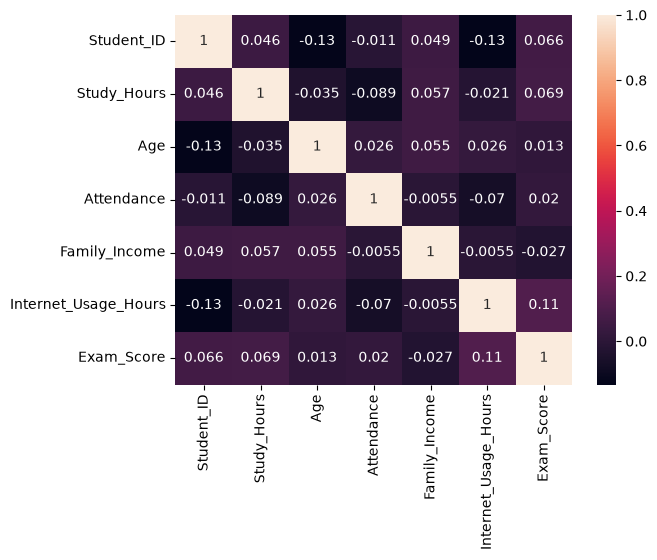

In [11]:

import seaborn as sns
sns.heatmap(corr_matrix,annot = True)

In [18]:
mean_attendance = df.groupby("Age")["Attendance"].transform("mean")
mean_attendance

0     84.837500
1     84.837500
2     79.193333
3     79.493571
4     83.240714
        ...    
95    84.837500
96    83.240714
97    83.240714
98    79.493571
99    82.160625
Name: Attendance, Length: 100, dtype: float64

In [17]:
mask_Atten = df["Attendance"].isna()
mask_Atten

0     False
1     False
2     False
3     False
4     False
      ...  
95    False
96    False
97    False
98    False
99    False
Name: Attendance, Length: 100, dtype: bool

In [ ]:
df.loc[mask_Atten, "Attendance"] = mean_attendance[mask_Atten]

In [14]:
df.isna().sum()

Student_ID              0
Study_Hours             0
Age                     0
Attendance              0
Family_Income           0
Internet_Usage_Hours    2
Exam_Score              0
dtype: int64

In [19]:
mean_internet = df.groupby("Age")["Internet_Usage_Hours"].transform("mean")
mask_Internet = df["Internet_Usage_Hours"].isna()
df.loc[mask_Internet, "Internet_Usage_Hours"] = mean_internet[mask_Internet]

In [20]:
df.isna().sum()

Student_ID              0
Study_Hours             0
Age                     0
Attendance              0
Family_Income           0
Internet_Usage_Hours    0
Exam_Score              0
dtype: int64

In [21]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer

In [22]:
trf1 = ColumnTransformer(
    [
    ('impute_numerical',SimpleImputer(strategy="mean"),["Attendance","Internet_Usage_Hours"]
     )
    ],
    remainder="passthrough",verbose_feature_names_out=False).set_output(transform = "pandas")

In [30]:
from sklearn.compose import ColumnTransformer
trf2=ColumnTransformer([(
    'scaling',
    MinMaxScaler(),
    ['Student_ID', 'Study_Hours', 'Age', 'Attendance', 'Family_Income',
       'Internet_Usage_Hours', 'Exam_Score']
)],
remainder='passthrough',
verbose_feature_names_out=False).set_output(transform='pandas')

In [31]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('trans1', trf1),
    ('trans2', trf2),

])

In [32]:
final_output = pipe.fit_transform(df)
print(final_output)
print('\nNull values in final output:')
print(final_output.isna().sum())
print('\nTotal null values:', final_output.isna().sum().sum())

    Student_ID  Study_Hours       Age  Attendance  Family_Income  \
0     0.000000     0.307692  1.000000    0.369570       0.118586   
1     0.010101     0.180663  1.000000    0.456854       0.137082   
2     0.020202     0.164432  0.857143    0.745090       0.428245   
3     0.030303     0.164432  0.285714    0.744892       0.062505   
4     0.040404     0.625970  0.000000    0.745090       0.211754   
..         ...          ...       ...         ...            ...   
95    0.959596     0.097389  1.000000    0.767903       0.412418   
96    0.969697     0.734651  0.000000    0.478476       0.012842   
97    0.979798     0.302047  0.000000    0.531839       0.061920   
98    0.989899     0.068454  0.285714    0.791113       0.121910   
99    1.000000     0.379675  0.714286    0.763936       0.127382   

    Internet_Usage_Hours  Exam_Score  
0               0.372161    0.515396  
1               0.739194    0.333394  
2               0.482051    0.190249  
3               0.068864   

In [33]:
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('trans1', ...), ('trans2', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Student_ID','Study_Hours','Age',...,'Family_Income', 'Internet_Usage_Hours','Exam_Score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('impute_numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subse

In [34]:
df.isna().sum()

Student_ID              0
Study_Hours             0
Age                     0
Attendance              0
Family_Income           0
Internet_Usage_Hours    0
Exam_Score              0
dtype: int64

<Figure size 500x600 with 0 Axes>

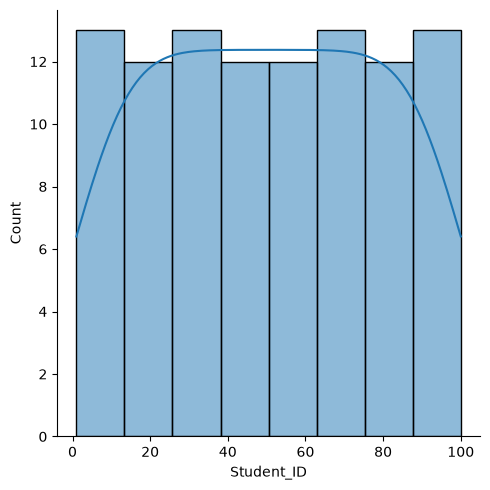

<Figure size 500x600 with 0 Axes>

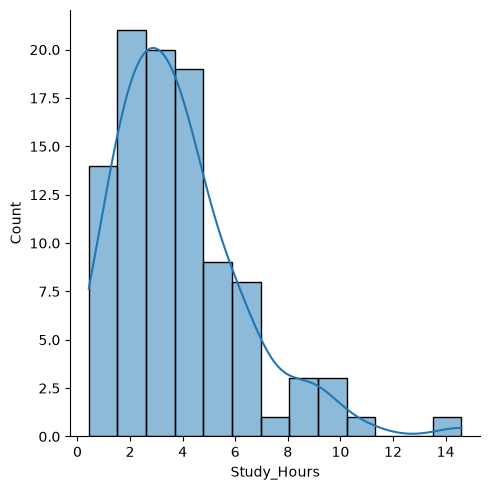

<Figure size 500x600 with 0 Axes>

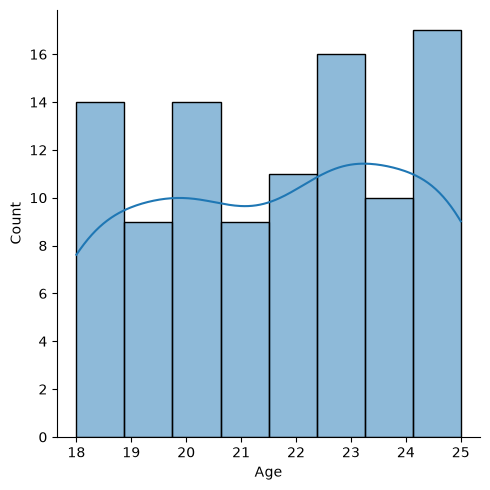

<Figure size 500x600 with 0 Axes>

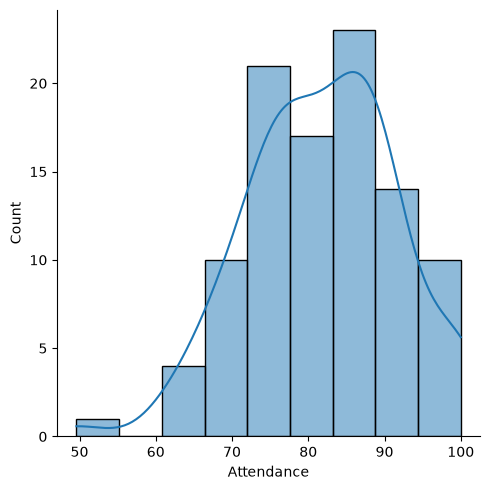

<Figure size 500x600 with 0 Axes>

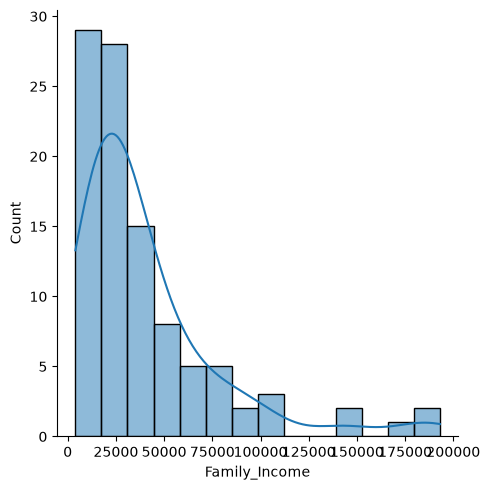

<Figure size 500x600 with 0 Axes>

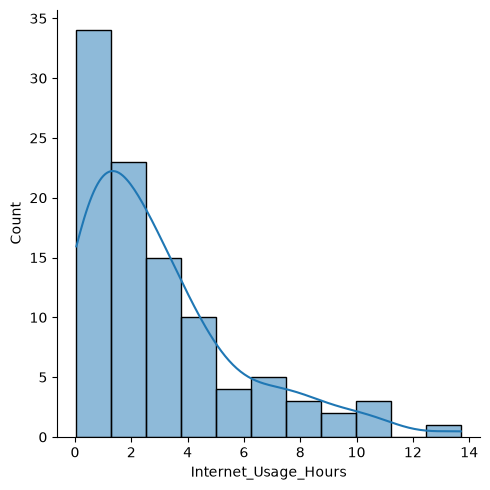

<Figure size 500x600 with 0 Axes>

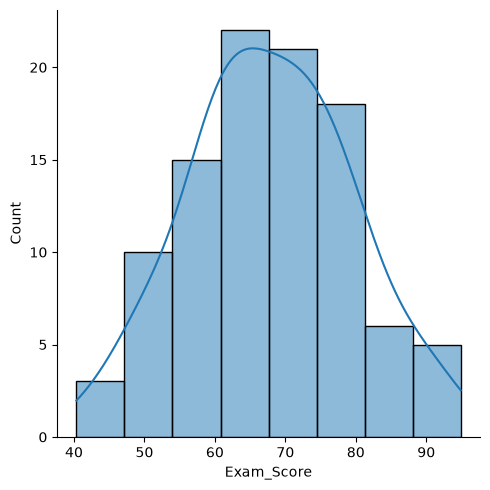

In [36]:
from matplotlib.figure import SubFigure
import matplotlib.pyplot as plt
import seaborn as sns
cols = df.columns.tolist()
for col in cols:
    plt.figure(figsize=(5,6))
    sns.displot(df[col],kde=True)
    plt.show()


===Log Transformation===
---After log transformation of Student_ID---
-1.5339876333360143
---After log transformation of Study_Hours---
-0.5680524612827917
---After log transformation of Age---
-0.22114358082995278
---After log transformation of Attendance---
-0.7269108761049848
---After log transformation of Family_Income---
0.19772072439896993
---After log transformation of Internet_Usage_Hours---
-0.6518175975771114
---After log transformation of Exam_Score---
-0.40353585241355666


<Figure size 600x400 with 0 Axes>

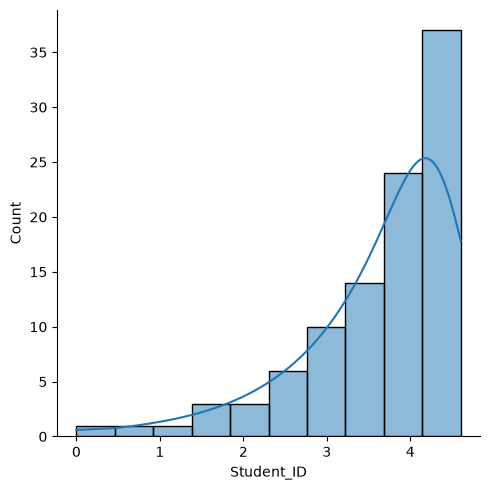

<Figure size 600x400 with 0 Axes>

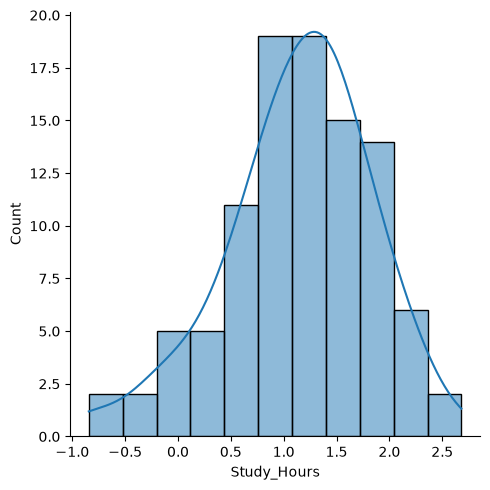

<Figure size 600x400 with 0 Axes>

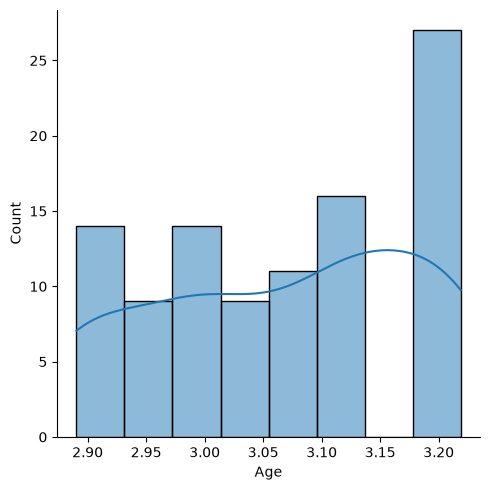

<Figure size 600x400 with 0 Axes>

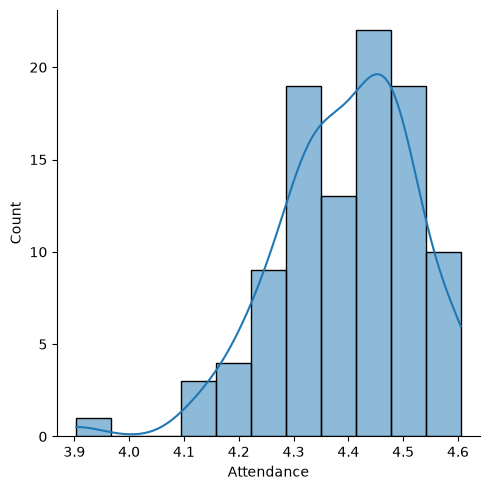

<Figure size 600x400 with 0 Axes>

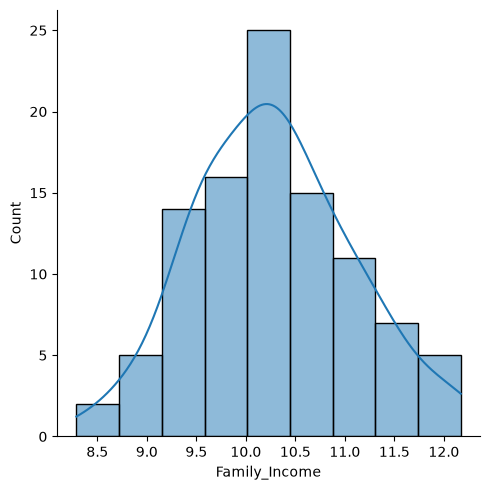

<Figure size 600x400 with 0 Axes>

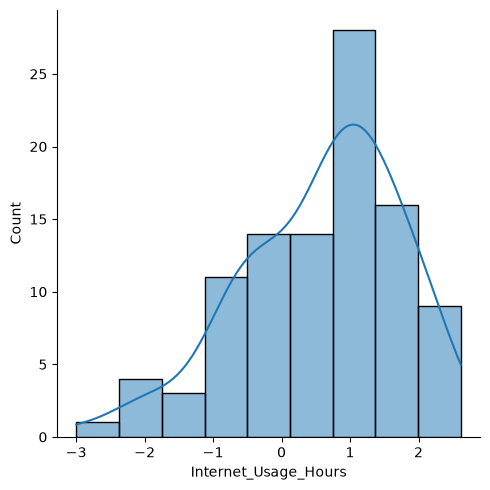

<Figure size 600x400 with 0 Axes>

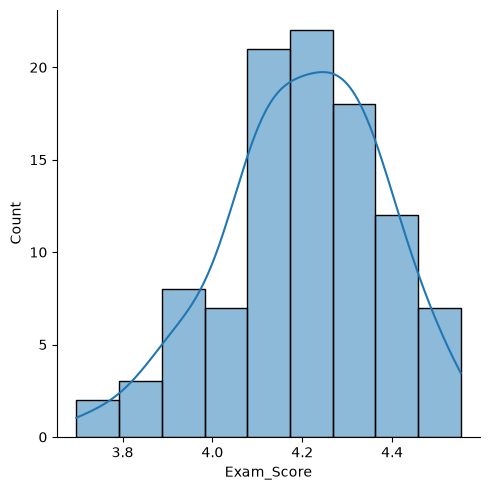

In [38]:
from scipy.stats import gaussian_kde, skew
import numpy as np
print("===Log Transformation===")
for col in cols:
    log_data = np.log(df[col])
    print(f"---After log transformation of {col}---")      
    print(skew(log_data))
    plt.figure(figsize=(6,4))
    sns.displot(log_data,kde=True)
    plt.show

===Log Transformation===
---After log transformation of Student_ID---
-1.317572059266389
---After log transformation of Study_Hours---
-0.00969388869999056
---After log transformation of Age---
-0.21578893910683067
---After log transformation of Attendance---
-0.7199209108206821
---After log transformation of Family_Income---
0.19780977173090397
---After log transformation of Internet_Usage_Hours---
0.23658683757829937
---After log transformation of Exam_Score---
-0.3962467282073046


<Figure size 600x400 with 0 Axes>

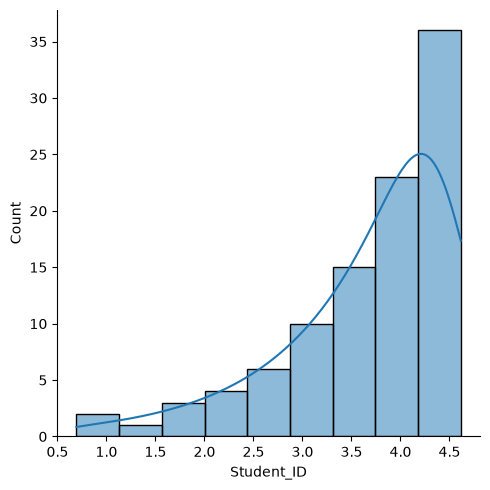

<Figure size 600x400 with 0 Axes>

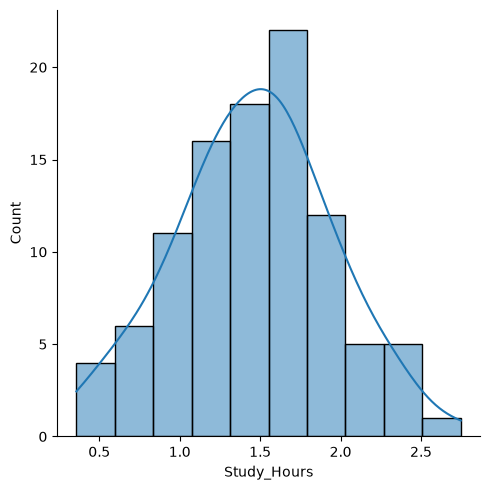

<Figure size 600x400 with 0 Axes>

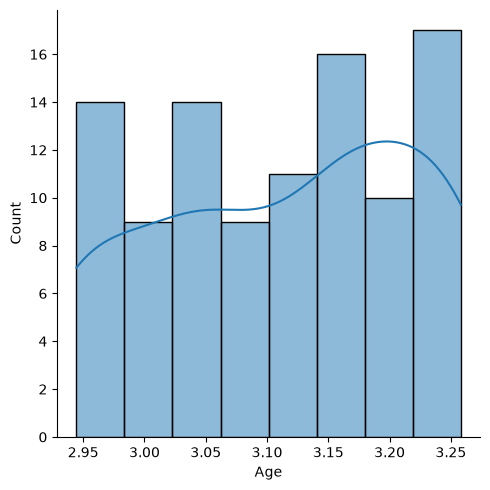

<Figure size 600x400 with 0 Axes>

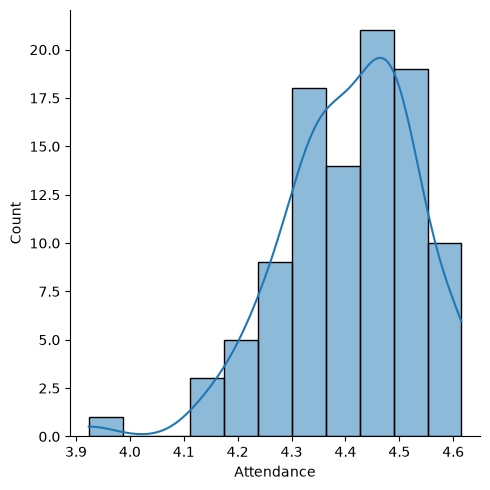

<Figure size 600x400 with 0 Axes>

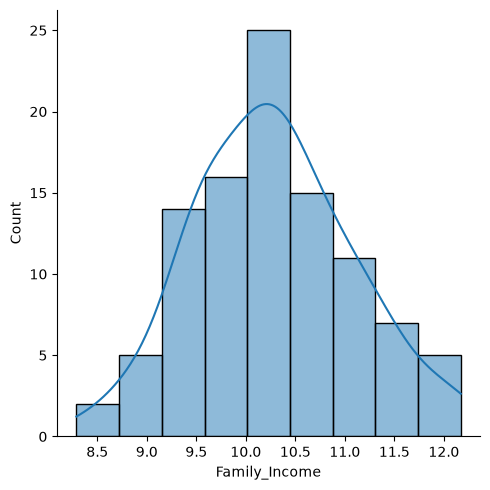

<Figure size 600x400 with 0 Axes>

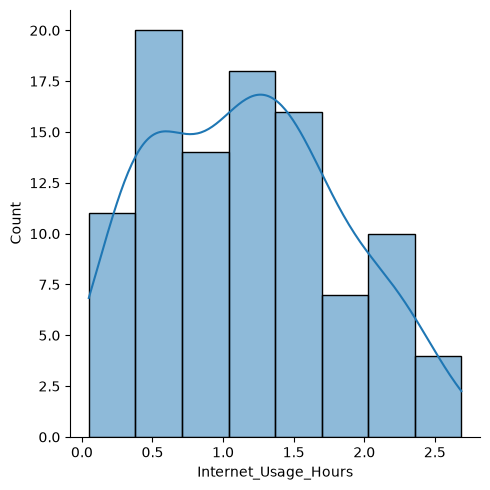

<Figure size 600x400 with 0 Axes>

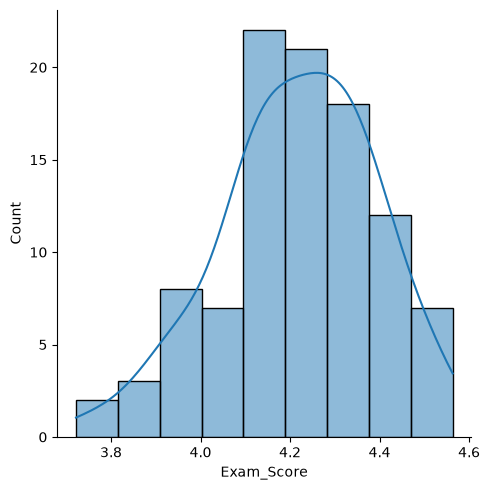

In [39]:
import numpy as np
print("===Log Transformation===")
for col in cols:
    log_data = np.log1p(df[col])
    print(f"---After log transformation of {col}---")      
    print(skew(log_data))
    plt.figure(figsize=(6,4))
    sns.displot(log_data,kde=True)
    plt.show

===Log Transformation===
---After log transformation of Student_ID---
-0.5381849382599901
---After log transformation of Study_Hours---
0.45307781244976447
---After log transformation of Age---
-0.16175557227483997
---After log transformation of Attendance---
-0.48656261851069377
---After log transformation of Family_Income---
1.2279702660003355
---After log transformation of Internet_Usage_Hours---
0.5251885054191543
---After log transformation of Exam_Score---
-0.17754036097999226


<Figure size 600x400 with 0 Axes>

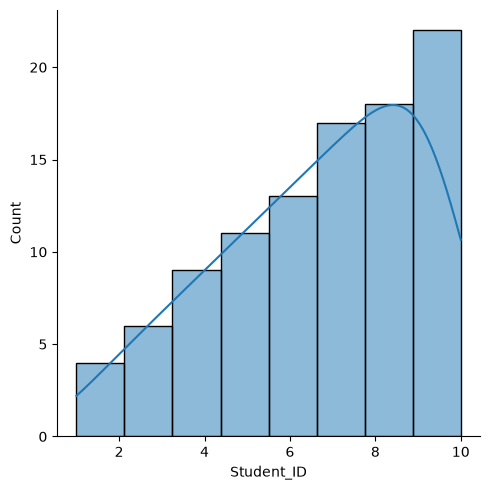

<Figure size 600x400 with 0 Axes>

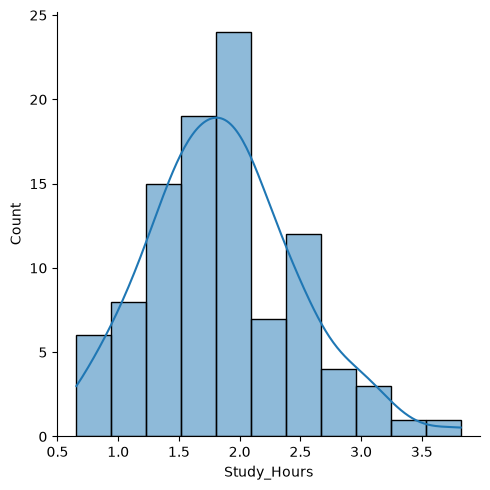

<Figure size 600x400 with 0 Axes>

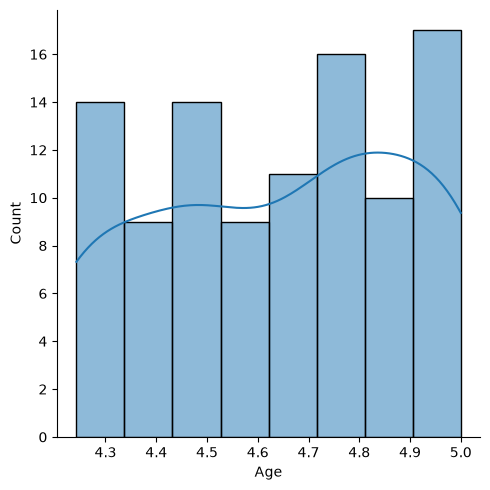

<Figure size 600x400 with 0 Axes>

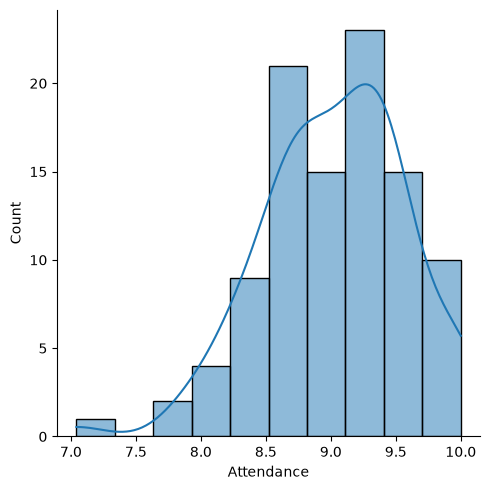

<Figure size 600x400 with 0 Axes>

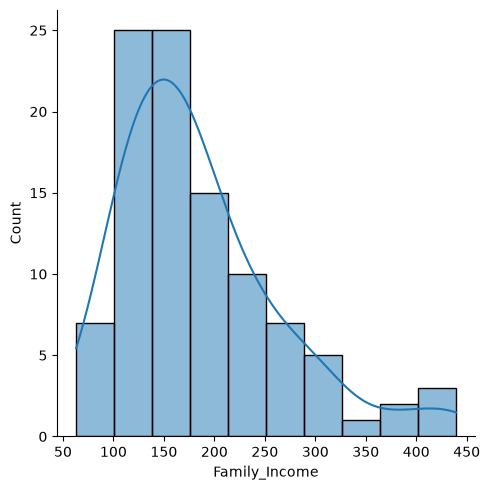

<Figure size 600x400 with 0 Axes>

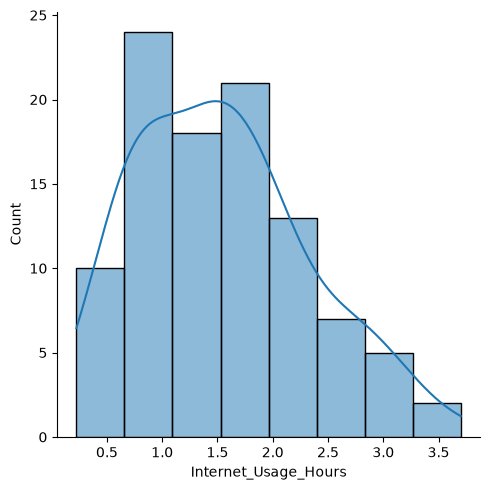

<Figure size 600x400 with 0 Axes>

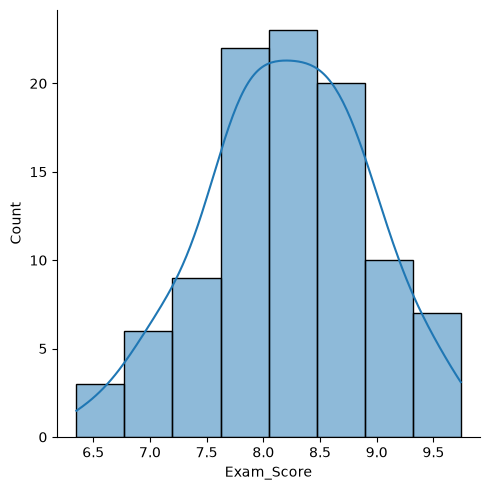

In [40]:
import numpy as np
print("===Log Transformation===")
for col in cols:
    log_data = np.sqrt(df[col])
    print(f"---After log transformation of {col}---")      
    print(skew(log_data))
    plt.figure(figsize=(6,4))
    sns.displot(log_data,kde=True)
    plt.show

===Log Transformation===
---After boxcox0.7170160498367874---
-0.2716588095806779
---After boxcox0.2720661415245264---
-0.0010955199947447604
---After boxcox1.327010870890467---
-0.06417584789934923
---After boxcox1.7296065039694408---
-0.00915449379490411
---After boxcox-0.09037326235748809---
0.005049676728752633
---After boxcox0.23031338760951006---
-0.056931222110348734
---After boxcox0.8671204448294709---
-0.018363855102191837


<Figure size 600x400 with 0 Axes>

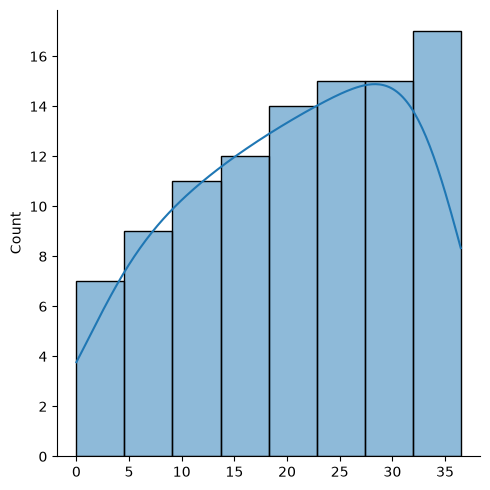

<Figure size 600x400 with 0 Axes>

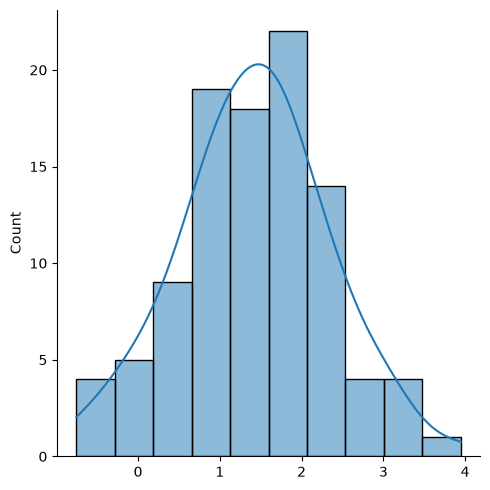

<Figure size 600x400 with 0 Axes>

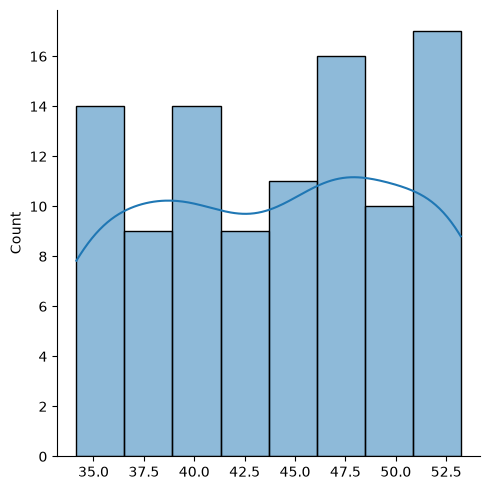

<Figure size 600x400 with 0 Axes>

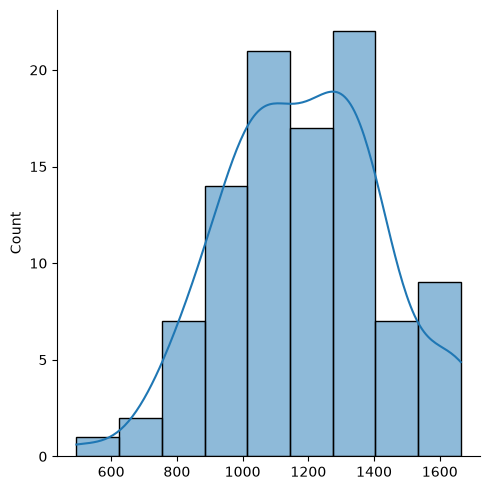

<Figure size 600x400 with 0 Axes>

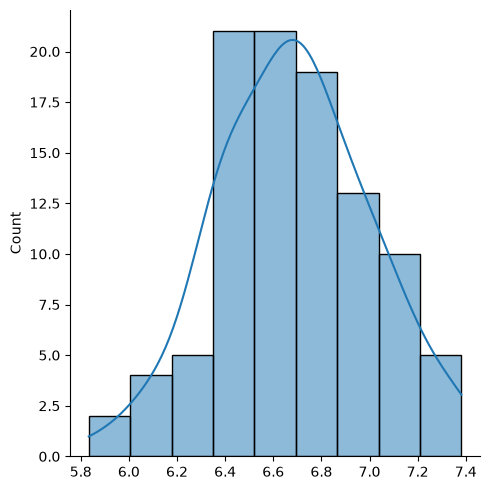

<Figure size 600x400 with 0 Axes>

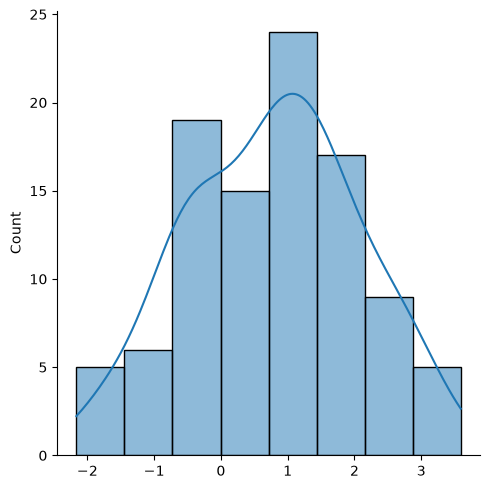

<Figure size 600x400 with 0 Axes>

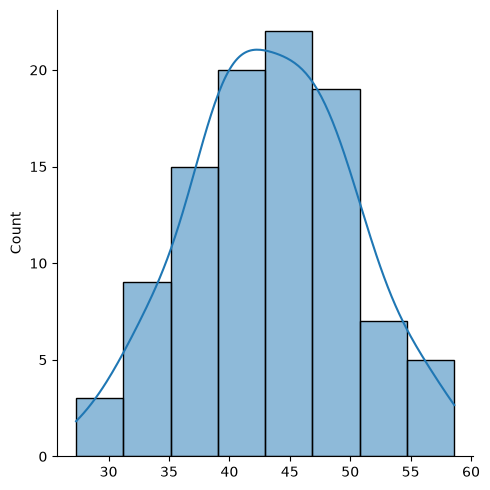

In [41]:
from scipy.stats import boxcox, yeojohnson
import numpy as np
print("===Log Transformation===")
for col in cols:
    data,l = boxcox(df[col])
    print(f"---After boxcox{l}---")      
    print(skew(data))
    plt.figure(figsize=(6,4))
    sns.displot(data,kde=True)
    plt.show


===Log Transformation===
---After boxcox0.7235624813465434---
-0.25203046025376785
---After boxcox0.007217082807872859---
-0.00021075313062609378
---After boxcox1.3561890152670883---
-0.0626195365300947
---After boxcox1.7392845288498275---
-0.009081231371304338
---After boxcox-0.09042077087823212---
0.005054156901601026
---After boxcox-0.18734791514422677---
0.038816415486058534
---After boxcox0.8658095064731975---
-0.01805207515648831


<Figure size 600x400 with 0 Axes>

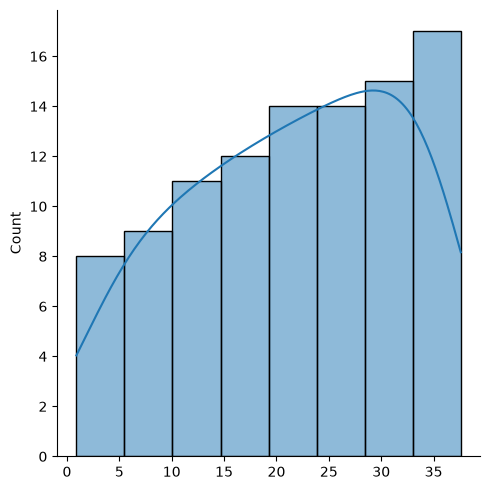

<Figure size 600x400 with 0 Axes>

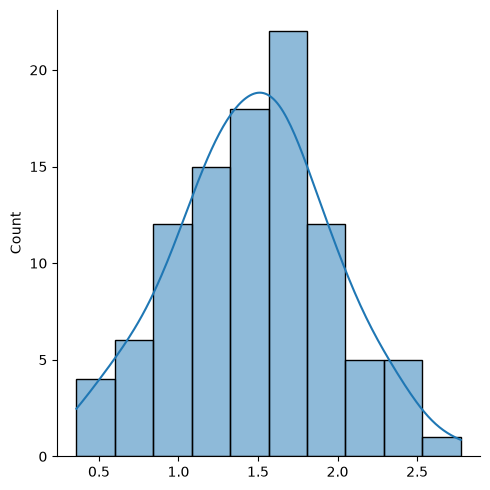

<Figure size 600x400 with 0 Axes>

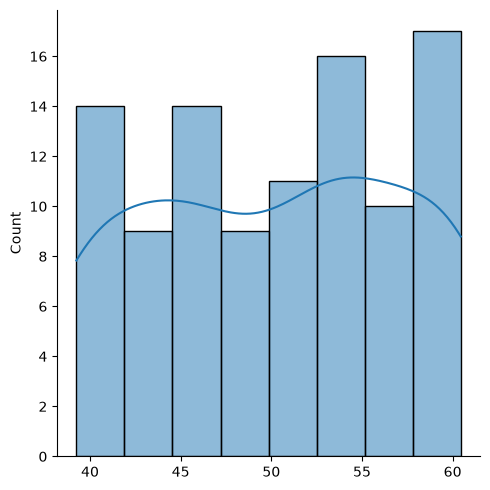

<Figure size 600x400 with 0 Axes>

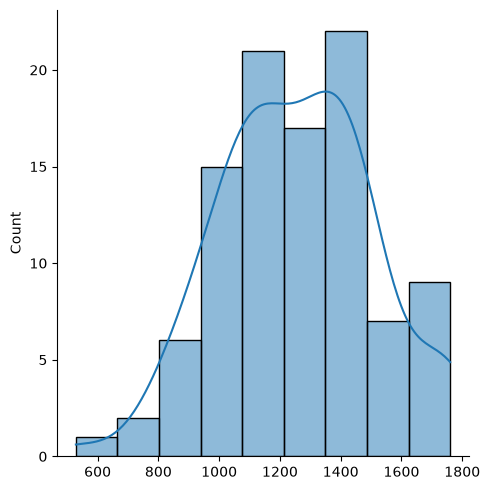

<Figure size 600x400 with 0 Axes>

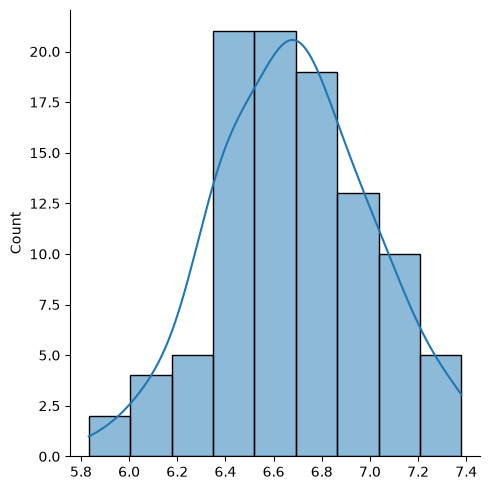

<Figure size 600x400 with 0 Axes>

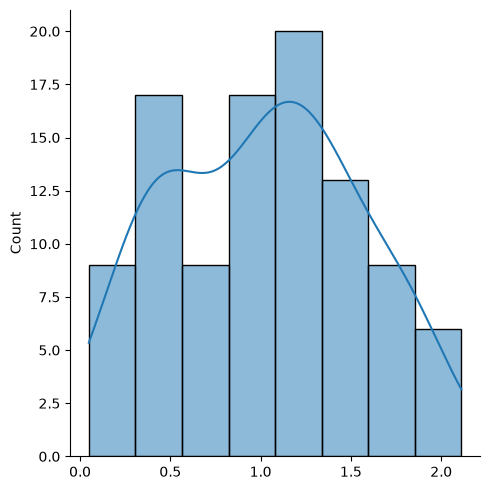

<Figure size 600x400 with 0 Axes>

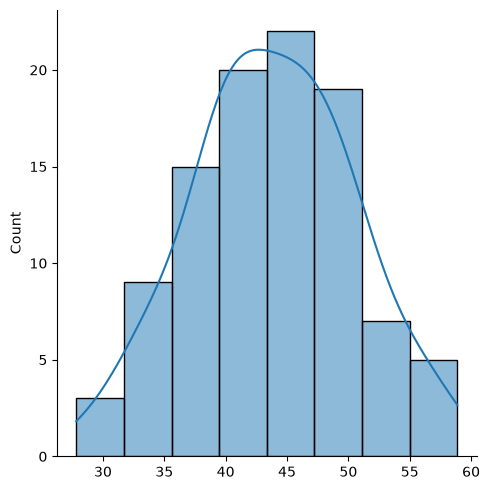

In [42]:
from scipy.stats import boxcox, yeojohnson
import numpy as np
print("===Log Transformation===")
for col in cols:
    data,l = yeojohnson(df[col])
    print(f"---After boxcox{l}---")  
    print(skew(data))
    plt.figure(figsize=(6,4))
    sns.displot(data,kde=True)
    plt.show